$\LARGE{Least\ Squares\ Line\ fitting}$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

In [5]:
#Least squares function
def LS_fitting(X, y):
    #The line model y = mx + b
    #Need to find m and b

    #Matrix X
    mat_X = np.column_stack([X, np.ones(len(X))])
    mat_Y = y

    #The matrix m and b 
    # The matrix B = (X^T * X)^-1 * X^T * Y
    B = np.linalg.inv(mat_X.T @ mat_X) @ mat_X.T @ mat_Y

    return B

In [10]:
#Testing on a dataset

#Parameters
true_w1 = 3.5
true_w2 = -2.0
true_b = 10.0

#Generate random X data 
num_samples = 100
#Creates a 100x2 matrix of random numbers between 0 and 10
X = np.random.rand(num_samples, 2) * 10 

#Calculate the pure y values
#x[:, 0] is for the first column i.e x1 similarly X[:, 1] is for second column i.e x2
y_pure = (true_w1 * X[:, 0]) + (true_w2 * X[:, 1]) + true_b

#Adding random noise
noise = np.random.normal(loc=0.0, scale=2.0, size=num_samples)
y_noisy = y_pure + noise

#Running the function
predicted_B = LS_fitting(X, y_noisy)

print(f"Predicted Parameters: {np.round(predicted_B, 2)}")

Predicted Parameters: [ 3.58 -2.19 10.72]


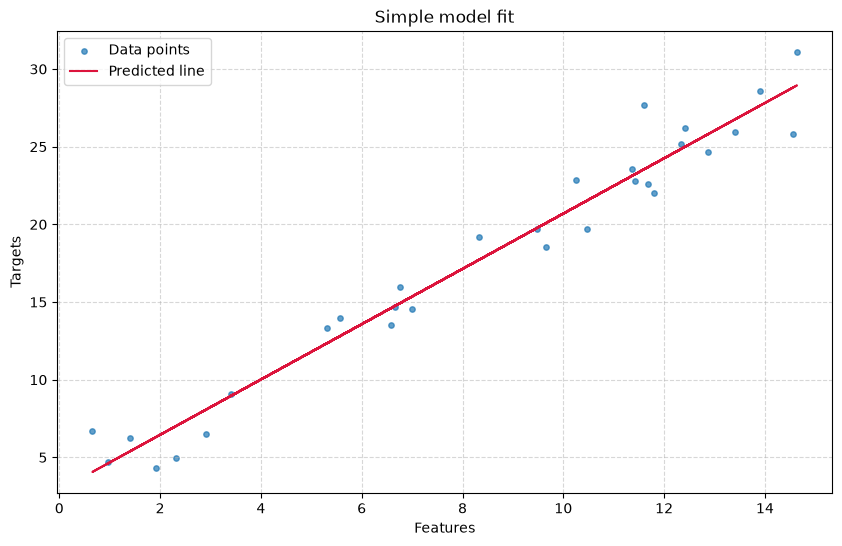

In [37]:
#Plotting a 1D X, y dataset
rng = np.random.default_rng(42)
X = rng.uniform(0, 15, size=(30, 1))
y = 2.5 + 1.8 * X[:, 0] + rng.normal(0, 2, size=30)

#Prediction
predicted_B = LS_fitting(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label = 'Data points', alpha = 0.7, s = 15)
plt.plot(X, X*predicted_B[0] + predicted_B[1], color='crimson', label='Predicted line')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Simple model fit')
plt.legend(loc='upper left')
plt.show()

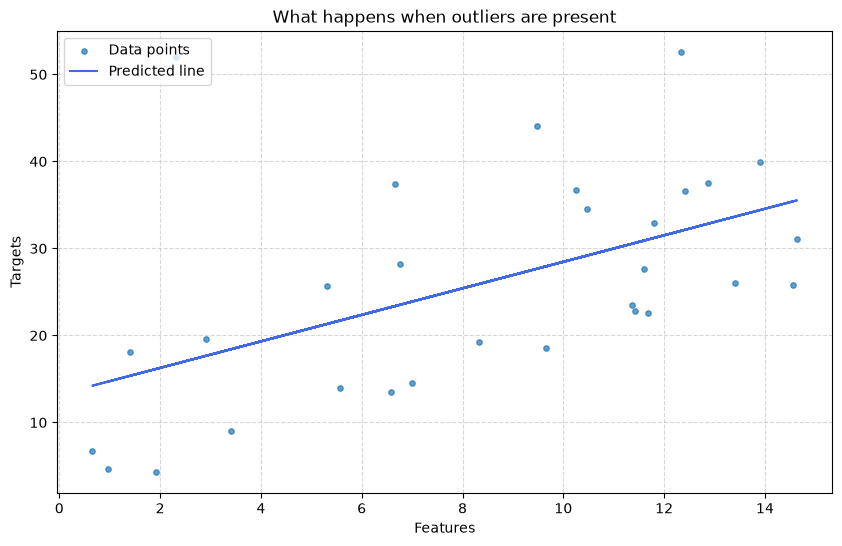

In [42]:
#What happens when the outliers are present
outlier_index = rng.choice(len(y), size = 5, replace = False)
y[outlier_index] += rng.uniform(10, 15, size=5)

#Prediction
predicted_B = LS_fitting(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label = 'Data points', alpha = 0.7, s = 15)
plt.plot(X, X*predicted_B[0] + predicted_B[1], color='royalblue', label='Predicted line')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('What happens when outliers are present')
plt.legend(loc='upper left')
plt.show()

In [43]:
#Trying to fit for a vertical line
X_vertical = np.array([5.0, 5.0, 5.0, 5.0, 5.0])
y_vertical = np.array([1.0, 2.0, 3.0, 4.0, 5.0])

try:
    predicted_B = LS_fitting(X_vertical, y_vertical)
    print(predicted_B)
except Exception as e:
    print(f"Can't  fit:\n{e}")

Can't  fit:
Singular matrix


$\LARGE{Total\ Least\ Squares\ Fitting}$

In [48]:
#Total least squares function
def TLS_fitting(X, y):

    #Taking the means
    X_bar = np.mean(X)
    y_bar = np.mean(y)

    #Centroid vector
    centroid = np.array([X_bar, y_bar])

    mat_U = np.column_stack([X - X_bar, y - y_bar])

    #Getting the eigne vectors of (U^T)(U)
    eig_vals, eig_vectors = np.linalg.eig(mat_U.T @ mat_U)

    #Getting the minimum eigen value
    min_eig_val_idx = np.argmin(eig_vals)

    #Getting the eigenvector corresponds to the minimum eigenvalue
    min_eig_vector = eig_vectors[:,min_eig_val_idx]

    #The constant value
    d = np.dot(min_eig_vector, centroid)

    #Parameters vector
    parameters = np.append(min_eig_vector, d)

    return parameters

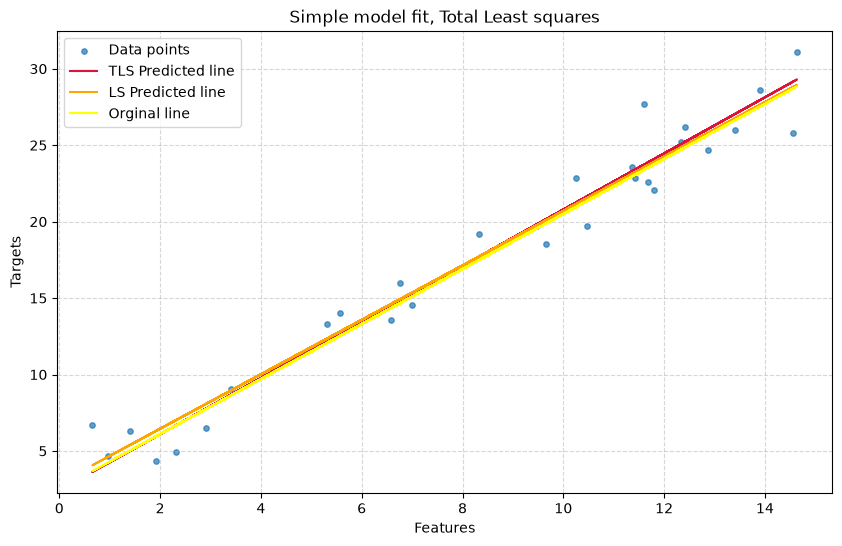

In [56]:
#Using the same above data set
#Plotting a 1D X, y dataset
rng = np.random.default_rng(42)
X = rng.uniform(0, 15, size=(30, 1))
y = 2.5 + 1.8 * X[:, 0] + rng.normal(0, 2, size=30)

#Prediction
predicted_B = LS_fitting(X, y)
parameters = TLS_fitting(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label = 'Data points', alpha = 0.7, s = 15)
plt.plot(X, (- X*parameters[0] + parameters[2])/(parameters[1]), color='crimson', label='TLS Predicted line')
plt.plot(X, X*predicted_B[0] + predicted_B[1], color='orange', label='LS Predicted line')
plt.plot(X, 2.5 + 1.8*X, color='yellow', label='Orginal line')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Simple model fit, Total Least squares')
plt.legend(loc='upper left')
plt.show()

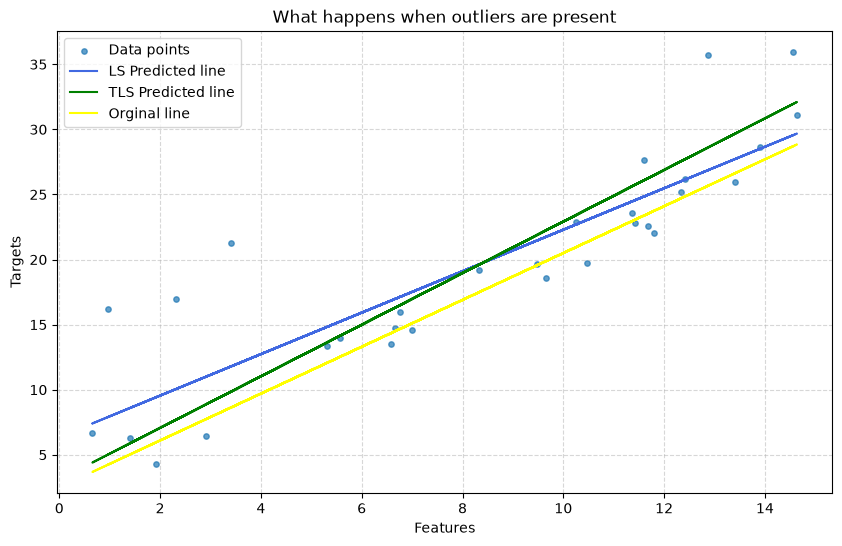

In [55]:
#The effect of outliers
outlier_index = rng.choice(len(y), size = 5, replace = False)
y[outlier_index] += rng.uniform(10, 15, size=5)

#Prediction
predicted_B = LS_fitting(X, y)
parameters = TLS_fitting(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label = 'Data points', alpha = 0.7, s = 15)
plt.plot(X, X*predicted_B[0] + predicted_B[1], color='royalblue', label='LS Predicted line')
plt.plot(X, (- X*parameters[0] + parameters[2])/(parameters[1]), color='green', label='TLS Predicted line')
plt.plot(X, 2.5 + 1.8*X, color='yellow', label='Orginal line')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('What happens when outliers are present')
plt.legend(loc='upper left')
plt.show()

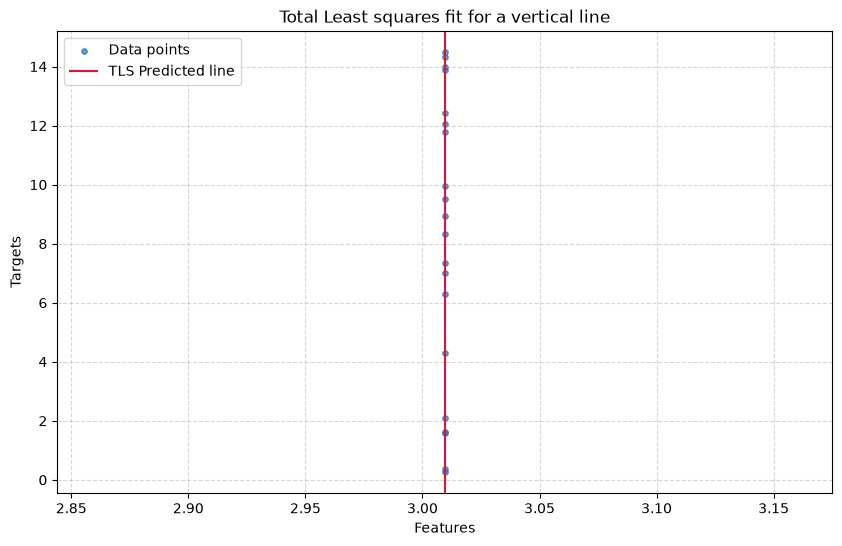

In [ ]:
#The advantage here is this can fit into vertical lines as well
#Trying to fit for a vertical line
x_value = rng.uniform(0, 10)
X_vertical = np.full((20, 1), x_value)
y_vertical = rng.uniform(0, 15, size=(20, 1))

try:
    parameters = TLS_fitting(X_vertical, y_vertical)
    plt.figure(figsize=(10, 6))
    plt.scatter(X_vertical, y_vertical, label='Data points', alpha=0.7, s=15)

    #TLS represents the line as a*x + b*y = d.
    #For a vertical line, b is approximately zero, so x = d/a.
    vertical_x = parameters[2] / parameters[0]
    plt.axvline(vertical_x, color='crimson', label='TLS Predicted line')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlabel('Features')
    plt.ylabel('Targets')
    plt.title('Total Least squares fit for a vertical line')
    plt.legend(loc='upper left')
    plt.show()

except Exception as e:
    print(f"Can't fit:\n{e}")